# Reducción de Dimensionalidad - Crímenes en Chicago

## 1. Importar Librerías y Cargar Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, SelectFpr, chi2, f_classif, mutual_info_classif
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Cargar dataset
df = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized_combined.csv")
test_df = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_standardized_test.csv")
print(f"\nColumnas: {list(df.columns)}")

df = df.drop(["Unnamed: 0", "Latitude_standardized", "Longitude_standardized"], axis=1, errors='ignore')
test_df = test_df.drop(["Unnamed: 0", "Latitude_standardized", "Longitude_standardized"], axis=1, errors='ignore')

print(f"Shape del dataset: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
df.head()


Columnas: ['Beat', 'Ward', 'Community Area', 'Day_sin', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day Time_Afternoon', 'Day Time_Early Morning', 'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq', 'Primary_Type_freq', 'Location_Description_freq', 'FBI_Code_freq', 'Crime_District_freq', 'Nearest_Police_Station_District_freq', 'Nearest_Police_Station_District_Name_freq', 'X Coordinate_standardized', 'Y Coordinate_standardized', 'Latitude_standardized', 'Longitude_standardized', 'Distance Crime To Police Station_standardized', 'Arrest_tag']
Shape del dataset: (194874, 24)

Columnas: ['Beat', 'Ward', 'Community Area', 'Day_sin', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day Time_Afternoon', 'Day Time_Early Morning', 'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq', 'Primary_Type_freq', 'Location_Description_freq', 'FBI_Code_freq', 'Crime_District_freq', 'Nearest_Police_Station_District_freq', 'Nearest_Po

,Beat,Ward,Community Area,Day_sin,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Day Time_Afternoon,Day Time_Early Morning,...,Primary_Type_freq,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq,X Coordinate_standardized,Y Coordinate_standardized,Distance Crime To Police Station_standardized,Arrest_tag
0,2234,21,75,-2.449294e-16,0.0,0.0,1.0,0.0,0.0,0.0,...,0.111732,0.273399,0.111732,0.031108,0.027327,0.027327,0.258609,-1.804119,-0.736689,0
1,2422,49,1,-7.818315e-01,0.0,1.0,0.0,0.0,0.0,0.0,...,0.228052,0.192536,0.231090,0.033871,0.038644,0.038644,0.048955,1.962958,0.272196,0
2,133,4,35,-7.818315e-01,1.0,0.0,0.0,0.0,0.0,0.0,...,0.228052,0.273399,0.231090,0.055786,0.022748,0.022748,0.873387,-0.078710,-0.691772,0
3,834,18,70,4.338837e-01,0.0,0.0,0.0,1.0,0.0,0.0,...,0.228052,0.003317,0.231090,0.067287,0.066335,0.066335,-0.539423,-1.220451,1.512089,0
4,832,16,66,-7.818315e-01,1.0,0.0,0.0,0.0,1.0,0.0,...,0.111732,0.192536,0.111732,0.067287,0.042205,0.042205,-0.244154,-0.865498,0.358421,0


## 2. Preparación de Datos

### 2.1 Split Estratificado Train/Test

In [4]:
# Separar features y target
X_train = df.drop('Arrest_tag', axis=1)
y_train = df['Arrest_tag']

X_test = test_df.drop('Arrest_tag', axis=1)
y_test = test_df['Arrest_tag']

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nDistribución de Arrest en Train:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print(X_train.columns)

Training set: (194874, 23)
Test set: (203517, 21)

Distribución de Arrest en Train:
Arrest_tag
0    55.56
1    44.44
Name: proportion, dtype: float64
Index(['Beat', 'Ward', 'Community Area', 'Day_sin', 'Season_Autumn',
       'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day Time_Afternoon',
       'Day Time_Early Morning', 'Day Time_Morning', 'Day Time_Night',
       'Domestic_tag', 'IUCR_freq', 'Primary_Type_freq',
       'Location_Description_freq', 'FBI_Code_freq', 'Crime_District_freq',
       'Nearest_Police_Station_District_freq',
       'Nearest_Police_Station_District_Name_freq',
       'X Coordinate_standardized', 'Y Coordinate_standardized',
       'Distance Crime To Police Station_standardized'],
      dtype='object')


### 2.2 Definir Features Numéricas y Categóricas

In [5]:
# Identificar features por tipo
num_features = [
    'X Coordinate_standardized', 
    'Y Coordinate_standardized', 
    'Distance Crime To Police Station_standardized',
    'Beat_standardized',
    'Ward',
    'Community Area',
    'Crime District'
]

cat_features = [
    'IUCR',
    'Primary Type',
    'Location Description',
    'FBI Code',
    'Nearest Police Station District',
    'Nearest Police Station District Name',
    'Season',
    'Day',
    'Day Time'
]

# Feature binaria
binary_features = ['Domestic']

print(f"Features numéricas: {len(num_features)}")
print(num_features)
print(f"\nFeatures categóricas: {len(cat_features)}")
print(cat_features)
print(f"\nFeatures binarias: {len(binary_features)}")
print(binary_features)

Features numéricas: 7
['X Coordinate_standardized', 'Y Coordinate_standardized', 'Distance Crime To Police Station_standardized', 'Beat_standardized', 'Ward', 'Community Area', 'Crime District']

Features categóricas: 9
['IUCR', 'Primary Type', 'Location Description', 'FBI Code', 'Nearest Police Station District', 'Nearest Police Station District Name', 'Season', 'Day', 'Day Time']

Features binarias: 1
['Domestic']


---

# PARTE 1: SELECCIÓN DE FEATURES (Métodos de Filtrado)

## 3. Análisis de Correlaciones

Primero analizamos correlaciones entre features de ubicacion para identificar redundancias.

Index(['Beat', 'Ward', 'Community Area', 'Day_sin', 'Season_Autumn',
       'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day Time_Afternoon',
       'Day Time_Early Morning', 'Day Time_Morning', 'Day Time_Night',
       'Domestic_tag', 'IUCR_freq', 'Primary_Type_freq',
       'Location_Description_freq', 'FBI_Code_freq', 'Crime_District_freq',
       'Nearest_Police_Station_District_freq',
       'Nearest_Police_Station_District_Name_freq',
       'X Coordinate_standardized', 'Y Coordinate_standardized',
       'Distance Crime To Police Station_standardized'],
      dtype='object')


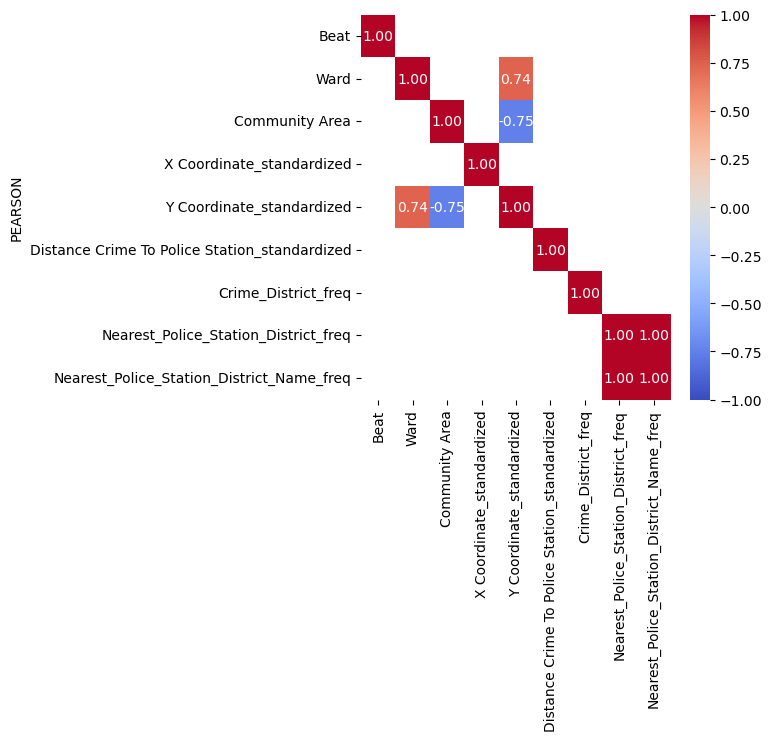

In [6]:
location_features = [
    'Beat', 
    'Ward',
    'Community Area', 
    'X Coordinate_standardized', 
    'Y Coordinate_standardized', 
    'Distance Crime To Police Station_standardized',
    'Crime_District_freq', 
    'Nearest_Police_Station_District_freq',
    'Nearest_Police_Station_District_Name_freq'
]

print(X_train.columns)
X_location = X_train[location_features]

umbral = 0.65

mask_for_heatmap = (X_location.corr(method='pearson').abs() < umbral)

plt.figure(figsize=(5,5))
sns.heatmap(
    X_location.corr(method='pearson'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=mask_for_heatmap)
plt.ylabel('PEARSON')
plt.show()



Matriz de correlación calculada
Shape: (10, 10)
TOP ID FEATURES MÁS CORRELACIONADAS CON 'Arrest'
X Coordinate_standardized                        0.049572
Distance Crime To Police Station_standardized    0.017667
Crime_District_freq                              0.014810
Beat                                             0.012129
Nearest_Police_Station_District_freq             0.009037
Nearest_Police_Station_District_Name_freq        0.009037
Ward                                             0.007107
Community Area                                   0.006210
Y Coordinate_standardized                        0.001722


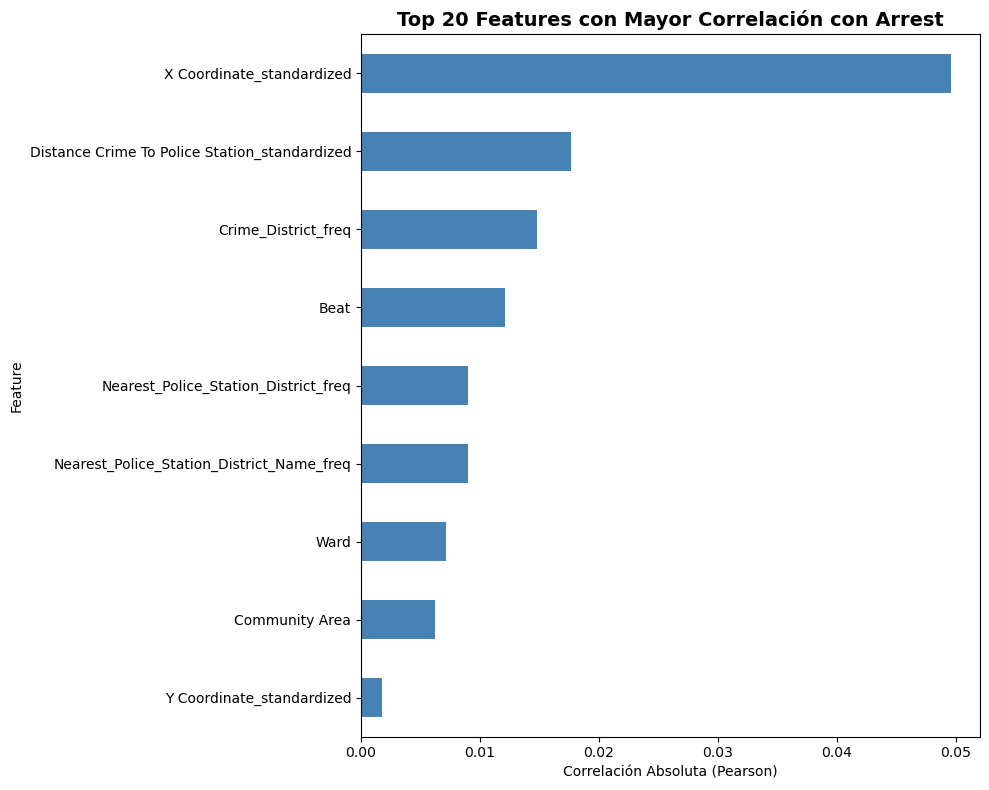

In [7]:
location_train_corr = X_location.copy()
location_train_corr['Arrest_tag'] = y_train

# Calcular matriz de correlación con Pearson
corr_matrix = location_train_corr.corr(method='pearson')

print("Matriz de correlación calculada")
print(f"Shape: {corr_matrix.shape}")
# Correlación de features con la variable target
target_corr = corr_matrix['Arrest_tag'].drop('Arrest_tag').abs().sort_values(ascending=False)

print("TOP ID FEATURES MÁS CORRELACIONADAS CON 'Arrest'")
print(target_corr.head(20).to_string())

# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
target_corr.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features con Mayor Correlación con Arrest', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación Absoluta (Pearson)')
ax.set_ylabel('Feature')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Según lo visualizado en el heatmap se puede proceder a eliminar las features, Beat, Ward, Community Area y Nearest Police Station District Name Freq

In [8]:
print(X_train.columns)
X_train = X_train.drop(['Beat', 'Ward', 'Community Area', 'Nearest_Police_Station_District_Name_freq'], axis=1).copy()
X_test = X_test.drop(['Beat', 'Ward', 'Community Area', 'Nearest_Police_Station_District_Name_freq'], axis=1)
print(X_train.columns)


Index(['Beat', 'Ward', 'Community Area', 'Day_sin', 'Season_Autumn',
       'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day Time_Afternoon',
       'Day Time_Early Morning', 'Day Time_Morning', 'Day Time_Night',
       'Domestic_tag', 'IUCR_freq', 'Primary_Type_freq',
       'Location_Description_freq', 'FBI_Code_freq', 'Crime_District_freq',
       'Nearest_Police_Station_District_freq',
       'Nearest_Police_Station_District_Name_freq',
       'X Coordinate_standardized', 'Y Coordinate_standardized',
       'Distance Crime To Police Station_standardized'],
      dtype='object')
Index(['Day_sin', 'Season_Autumn', 'Season_Spring', 'Season_Summer',
       'Season_Winter', 'Day Time_Afternoon', 'Day Time_Early Morning',
       'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq',
       'Primary_Type_freq', 'Location_Description_freq', 'FBI_Code_freq',
       'Crime_District_freq', 'Nearest_Police_Station_District_freq',
       'X Coordinate_standardized', 'Y Coordi

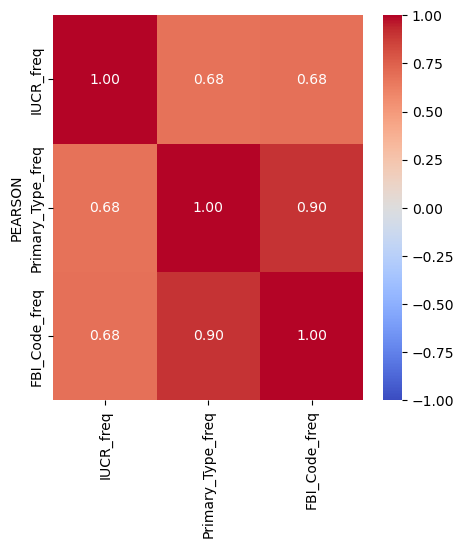

In [9]:
id_features = [
    'IUCR_freq', 
    'Primary_Type_freq',
    'FBI_Code_freq', 
]


X_id = X_train[id_features]

umbral = 0.65

mask_for_heatmap = (X_id.corr(method='pearson').abs() < umbral)

plt.figure(figsize=(5,5))
sns.heatmap(
    X_id.corr(method='pearson'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=mask_for_heatmap)
plt.ylabel('PEARSON')
plt.show()



Matriz de correlación calculada
Shape: (4, 4)
TOP ID FEATURES MÁS CORRELACIONADAS CON 'Arrest'
IUCR_freq            0.291446
FBI_Code_freq        0.272770
Primary_Type_freq    0.260158


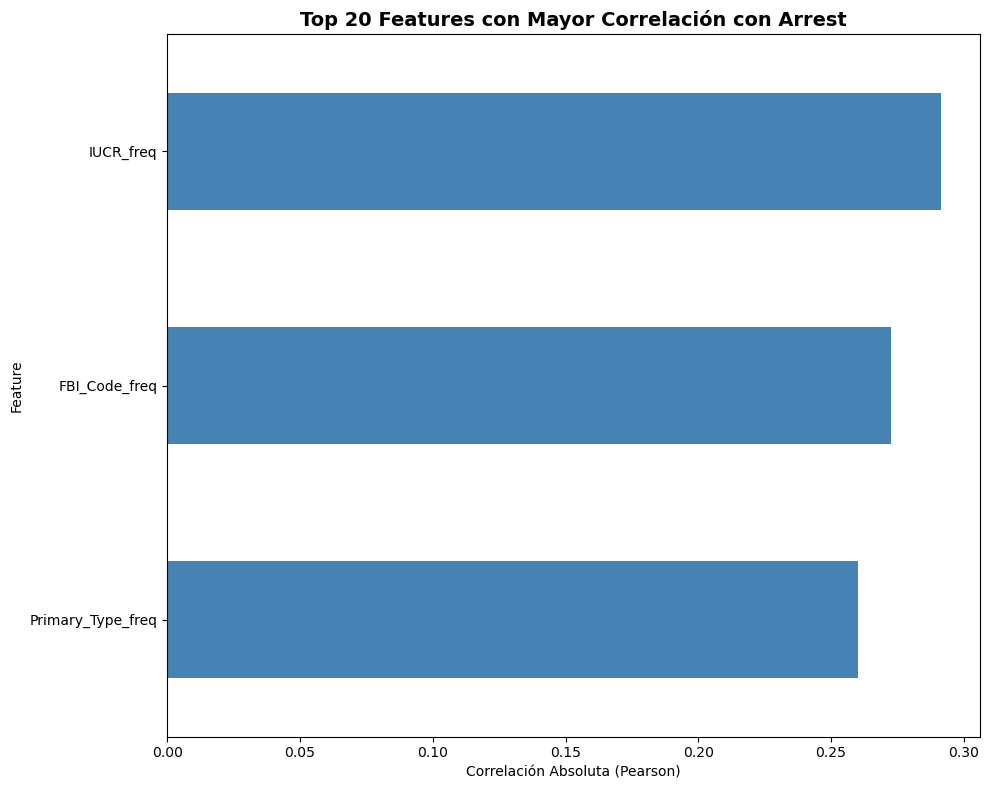

In [10]:
id_train_corr = X_id.copy()
id_train_corr['Arrest_tag'] = y_train

# Calcular matriz de correlación con Pearson
corr_matrix = id_train_corr.corr(method='pearson')

print("Matriz de correlación calculada")
print(f"Shape: {corr_matrix.shape}")
# Correlación de features con la variable target
target_corr = corr_matrix['Arrest_tag'].drop('Arrest_tag').abs().sort_values(ascending=False)

print("TOP ID FEATURES MÁS CORRELACIONADAS CON 'Arrest'")
print(target_corr.head(20).to_string())

# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
target_corr.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features con Mayor Correlación con Arrest', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación Absoluta (Pearson)')
ax.set_ylabel('Feature')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Se opta por eliminar solo FBI_Code_freq

In [11]:
print(X_train.columns)
X_train = X_train.drop(['FBI_Code_freq'], axis=1)
X_test = X_test.drop(['FBI_Code_freq'], axis=1)
print(X_train.columns)


Index(['Day_sin', 'Season_Autumn', 'Season_Spring', 'Season_Summer',
       'Season_Winter', 'Day Time_Afternoon', 'Day Time_Early Morning',
       'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq',
       'Primary_Type_freq', 'Location_Description_freq', 'FBI_Code_freq',
       'Crime_District_freq', 'Nearest_Police_Station_District_freq',
       'X Coordinate_standardized', 'Y Coordinate_standardized',
       'Distance Crime To Police Station_standardized'],
      dtype='object')
Index(['Day_sin', 'Season_Autumn', 'Season_Spring', 'Season_Summer',
       'Season_Winter', 'Day Time_Afternoon', 'Day Time_Early Morning',
       'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq',
       'Primary_Type_freq', 'Location_Description_freq', 'Crime_District_freq',
       'Nearest_Police_Station_District_freq', 'X Coordinate_standardized',
       'Y Coordinate_standardized',
       'Distance Crime To Police Station_standardized'],
      dtype='object')


## 4. Selección con ANOVA (F-test)

**Objetivo:** Identificar features numéricas con mayor poder predictivo sobre la variable target categórica.

**Hipótesis:**  
- H0: La media de la feature es igual para ambas clases (Arrest=0 y Arrest=1)  
- H1: Al menos una de las medias es diferente

**Criterio:** Mayor F-score = mayor poder predictivo

In [12]:
# Aplicar ANOVA solo a features numéricas
selector_anova = SelectKBest(score_func=f_classif, k='all')  # calcular todas
selector_anova.fit(X_train, y_train)

# Obtener scores y p-valores
anova_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Score': selector_anova.scores_,
    'P-Valor': selector_anova.pvalues_
}).sort_values('F-Score', ascending=False)

print("="*80)
print("ANOVA - F-TEST PARA FEATURES NUMÉRICAS")
print("="*80)
print(anova_scores.to_string(index=False))

ANOVA - F-TEST PARA FEATURES NUMÉRICAS
                                      Feature      F-Score       P-Valor
                                    IUCR_freq 18089.052657  0.000000e+00
                            Primary_Type_freq 14146.805187  0.000000e+00
                               Day Time_Night  1086.779372 1.119818e-237
                       Day Time_Early Morning   876.220065 3.879953e-192
                                 Domestic_tag   730.148472 1.648219e-160
                    X Coordinate_standardized   480.060773 2.787685e-106
                    Location_Description_freq   253.531435  4.793357e-57
                             Day Time_Morning   158.818502  2.118455e-36
                                Season_Winter   119.254146  9.385962e-28
Distance Crime To Police Station_standardized    60.841201  6.217351e-15
                          Crime_District_freq    42.750047  6.235314e-11
                                Season_Summer    24.942708  5.911036e-07
            

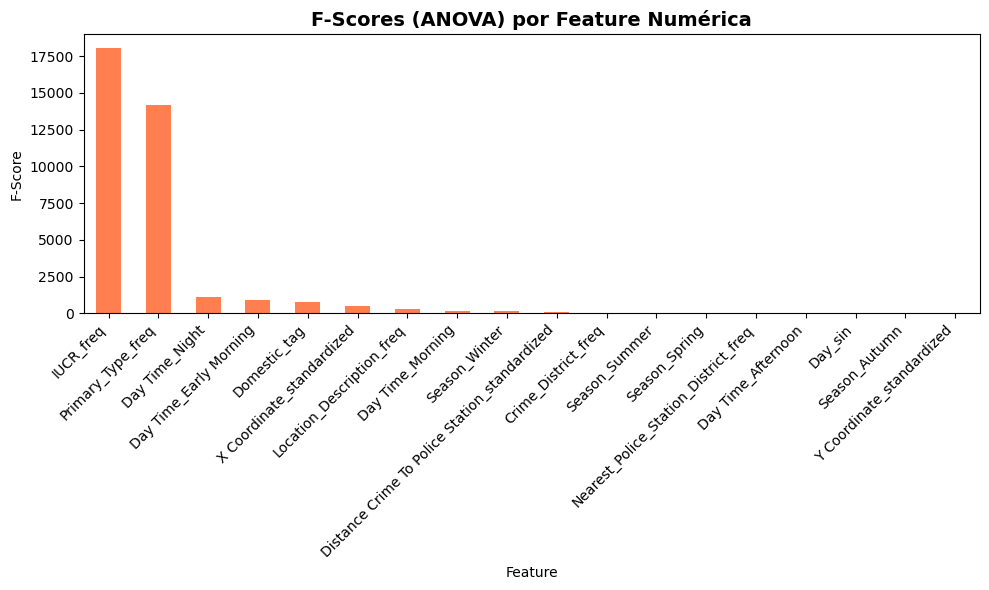


TOP 6 FEATURES NUMÉRICAS (ANOVA):
1. IUCR_freq                                | F-Score:   18089.05 | p-valor: 0.00e+00
2. Primary_Type_freq                        | F-Score:   14146.81 | p-valor: 0.00e+00
3. Day Time_Night                           | F-Score:    1086.78 | p-valor: 1.12e-237
4. Day Time_Early Morning                   | F-Score:     876.22 | p-valor: 3.88e-192
5. Domestic_tag                             | F-Score:     730.15 | p-valor: 1.65e-160
6. X Coordinate_standardized                | F-Score:     480.06 | p-valor: 2.79e-106


In [13]:
# Visualizar F-scores
fig, ax = plt.subplots(figsize=(10, 6))
anova_scores.plot(x='Feature', y='F-Score', kind='bar', ax=ax, color='coral', legend=False)
ax.set_title('F-Scores (ANOVA) por Feature Numérica', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('F-Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Seleccionar top K features
k_anova = 6
top_anova = anova_scores.head(k_anova)['Feature'].tolist()
print(f"\nTOP {k_anova} FEATURES NUMÉRICAS (ANOVA):")
for i, feat in enumerate(top_anova, 1):
    score = anova_scores[anova_scores['Feature']==feat]['F-Score'].values[0]
    pval = anova_scores[anova_scores['Feature']==feat]['P-Valor'].values[0]
    print(f"{i}. {feat:40s} | F-Score: {score:10.2f} | p-valor: {pval:.2e}")

In [14]:
selector_anova = SelectFpr(score_func=f_classif, alpha=0.05)  # usar f_regression cuando la v.a. target es numérica
X_train_num_best = selector_anova.fit_transform(X_train, y_train)
selected_indices = selector_anova.get_support()  # Esta función me devuelve los features seleccionados
selected_features = X_train.columns[selected_indices]
p_values = selector_anova.pvalues_
scores = selector_anova.scores_[selected_indices]
print(f"Numéricas antes de filtrar: {X_train.columns}")
print("\nCaracterísticas seleccionadas (ANOVA):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")
print("\nP-valores de todas las características:")
for feature, p_valor in zip(X_train.columns, p_values):
    print(f"{feature}: {p_valor}")

Numéricas antes de filtrar: Index(['Day_sin', 'Season_Autumn', 'Season_Spring', 'Season_Summer',
       'Season_Winter', 'Day Time_Afternoon', 'Day Time_Early Morning',
       'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq',
       'Primary_Type_freq', 'Location_Description_freq', 'Crime_District_freq',
       'Nearest_Police_Station_District_freq', 'X Coordinate_standardized',
       'Y Coordinate_standardized',
       'Distance Crime To Police Station_standardized'],
      dtype='object')

Características seleccionadas (ANOVA):
Season_Spring: 20.2806
Season_Summer: 24.9427
Season_Winter: 119.2541
Day Time_Afternoon: 6.7085
Day Time_Early Morning: 876.2201
Day Time_Morning: 158.8185
Day Time_Night: 1086.7794
Domestic_tag: 730.1485
IUCR_freq: 18089.0527
Primary_Type_freq: 14146.8052
Location_Description_freq: 253.5314
Crime_District_freq: 42.7500
Nearest_Police_Station_District_freq: 15.9172
X Coordinate_standardized: 480.0608
Distance Crime To Police Station_standard

## 6. Selección con Información Mutua (Mutual Information)

**Ventaja:** Captura relaciones no lineales entre features y target.

**Interpretación:** Mide cuánta "información" aporta una feature sobre el target.  
- MI = 0: Independientes  
- MI > 0: Existe dependencia

In [15]:
# Aplicar Información Mutua a TODAS las features
selector_mi = SelectKBest(score_func=mutual_info_classif, k='all')
selector_mi.fit(X_train, y_train)

# Obtener scores
mi_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'MI-Score': selector_mi.scores_
}).sort_values('MI-Score', ascending=False)

print("INFORMACIÓN MUTUA (MI) - TODAS LAS FEATURES")
print(mi_scores.head(30).to_string(index=False))

INFORMACIÓN MUTUA (MI) - TODAS LAS FEATURES
                                      Feature  MI-Score
                                    IUCR_freq  0.431831
                            Primary_Type_freq  0.353036
                    Location_Description_freq  0.250010
                                      Day_sin  0.204055
                    X Coordinate_standardized  0.099785
                    Y Coordinate_standardized  0.093220
Distance Crime To Police Station_standardized  0.069505
         Nearest_Police_Station_District_freq  0.031303
                               Day Time_Night  0.029041
                           Day Time_Afternoon  0.025843
                                Season_Summer  0.023405
                       Day Time_Early Morning  0.022925
                                Season_Spring  0.022495
                                Season_Autumn  0.022127
                                Season_Winter  0.021083
                             Day Time_Morning  0.020170
    

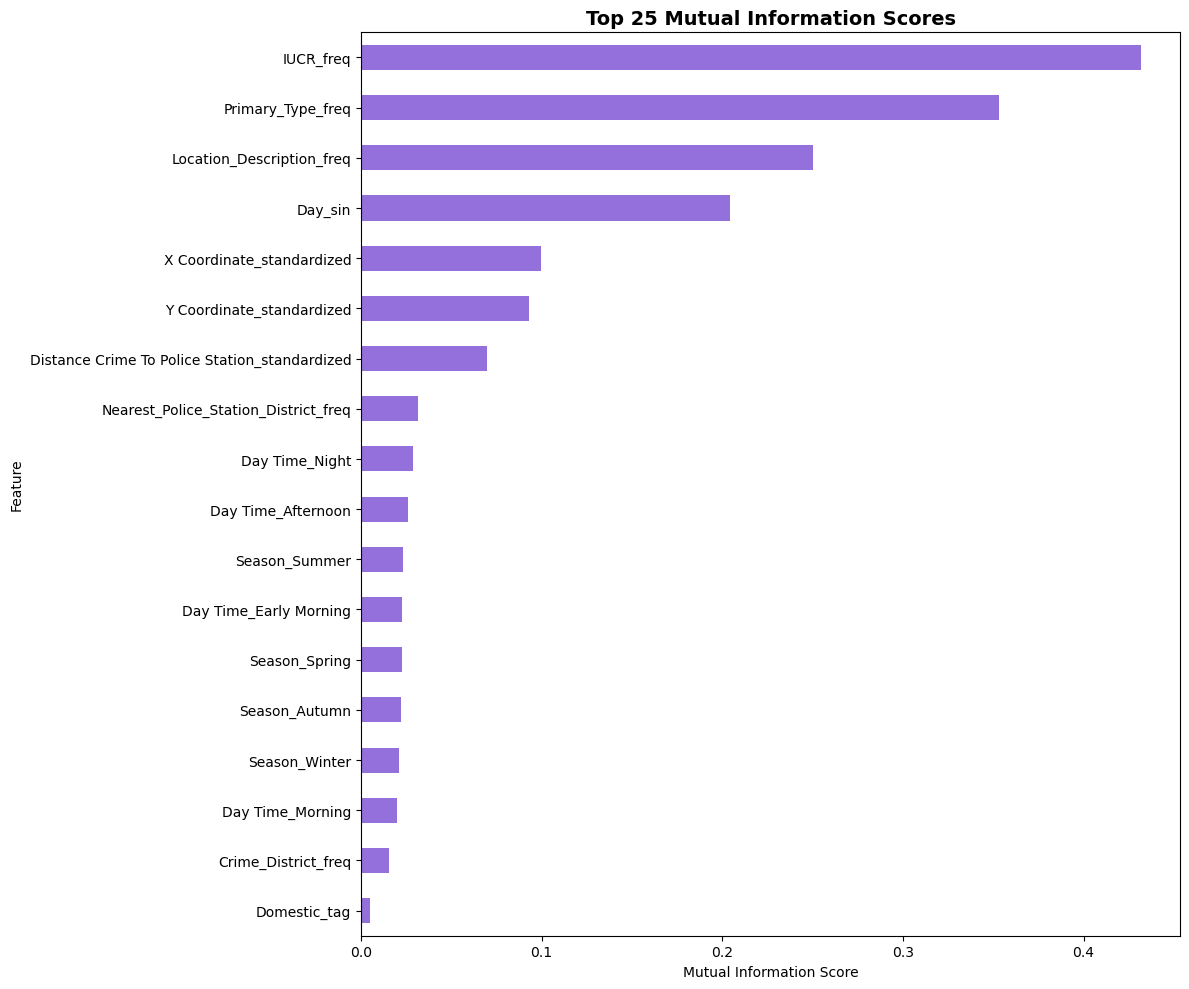


TOP 20 FEATURES (INFORMACIÓN MUTUA):
 1. IUCR_freq                                          | MI: 0.4318
 2. Primary_Type_freq                                  | MI: 0.3530
 3. Location_Description_freq                          | MI: 0.2500
 4. Day_sin                                            | MI: 0.2041
 5. X Coordinate_standardized                          | MI: 0.0998
 6. Y Coordinate_standardized                          | MI: 0.0932
 7. Distance Crime To Police Station_standardized      | MI: 0.0695
 8. Nearest_Police_Station_District_freq               | MI: 0.0313
 9. Day Time_Night                                     | MI: 0.0290
10. Day Time_Afternoon                                 | MI: 0.0258
11. Season_Summer                                      | MI: 0.0234
12. Day Time_Early Morning                             | MI: 0.0229
13. Season_Spring                                      | MI: 0.0225
14. Season_Autumn                                      | MI: 0.0221
15. Season

In [16]:
# Visualizar MI-scores
fig, ax = plt.subplots(figsize=(12, 10))
mi_scores.head(25).plot(x='Feature', y='MI-Score', kind='barh', ax=ax, color='mediumpurple', legend=False)
ax.set_title('Top 25 Mutual Information Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Mutual Information Score')
ax.set_ylabel('Feature')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Seleccionar top K features
k_mi = 20
top_mi = mi_scores.head(k_mi)['Feature'].tolist()
print(f"\nTOP {k_mi} FEATURES (INFORMACIÓN MUTUA):")
for i, feat in enumerate(top_mi, 1):
    score = mi_scores[mi_scores['Feature']==feat]['MI-Score'].values[0]
    print(f"{i:2d}. {feat:50s} | MI: {score:.4f}")

In [19]:
top_features = mi_scores[mi_scores['MI-Score'] > 0.008]['Feature']
X_train_top = X_train[top_features]
print(X_train.columns)
print(X_test.columns)
X_test_top = X_test[top_features]
# Unir X e y en un solo DataFrame
train_final = X_train_top.copy()
train_final['Arrest_tag'] = y_train.values

test_final = X_test_top.copy()
test_final['Arrest_tag'] = y_test.values

# Guardar datasets finales
train_final.to_csv("../datasets/chicago_crimes_and_stations_2024_final.csv", index=False)
test_final.to_csv("../datasets/chicago_crimes_and_stations_2024_final_test.csv", index=False)

Index(['Day_sin', 'Season_Autumn', 'Season_Spring', 'Season_Summer',
       'Season_Winter', 'Day Time_Afternoon', 'Day Time_Early Morning',
       'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq',
       'Primary_Type_freq', 'Location_Description_freq', 'Crime_District_freq',
       'Nearest_Police_Station_District_freq', 'X Coordinate_standardized',
       'Y Coordinate_standardized',
       'Distance Crime To Police Station_standardized'],
      dtype='object')
Index(['Day_sin', 'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Day Time_Early Morning', 'Day Time_Morning', 'Day Time_Night',
       'Domestic_tag', 'IUCR_freq', 'Primary_Type_freq',
       'Location_Description_freq', 'Crime_District_freq',
       'Nearest_Police_Station_District_freq', 'X Coordinate_standardized',
       'Y Coordinate_standardized',
       'Distance Crime To Police Station_standardized'],
      dtype='object')


KeyError: "['Day Time_Afternoon', 'Season_Autumn'] not in index"

---

# PARTE 2: EXTRACCIÓN DE FEATURES

## 8. PCA (Principal Component Analysis)

**Objetivo:** Reducir dimensionalidad transformando features en componentes principales ortogonales que capturan la máxima varianza.

**Ventajas:**
- Elimina multicolinealidad
- Reduce ruido
- Acelera entrenamiento

**Desventajas:**
- Pérdida de interpretabilidad
- Asume relaciones lineales

### 8.1 Determinar Número Óptimo de Componentes

In [ ]:
# Aplicar PCA con todos los componentes para análisis
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

# Varianza explicada por cada componente
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)


print("ANÁLISIS DE VARIANZA EXPLICADA - PCA")

print(f"\nVarianza explicada por los primeros 20 componentes:")
for i in range(min(20, len(explained_variance))):
    print(f"PC{i+1:2d}: {explained_variance[i]*100:5.2f}% | Acumulado: {cumulative_variance[i]*100:6.2f}%")

ANÁLISIS DE VARIANZA EXPLICADA - PCA

Varianza explicada por los primeros 20 componentes:
PC 1: 32.39% | Acumulado:  32.39%
PC 2: 21.33% | Acumulado:  53.72%
PC 3: 10.57% | Acumulado:  64.28%
PC 4:  9.48% | Acumulado:  73.76%
PC 5:  5.51% | Acumulado:  79.27%
PC 6:  5.32% | Acumulado:  84.59%
PC 7:  4.96% | Acumulado:  89.55%
PC 8:  4.22% | Acumulado:  93.77%
PC 9:  3.06% | Acumulado:  96.83%
PC10:  1.48% | Acumulado:  98.30%
PC11:  1.32% | Acumulado:  99.63%
PC12:  0.23% | Acumulado:  99.85%
PC13:  0.13% | Acumulado:  99.98%
PC14:  0.01% | Acumulado:  99.99%
PC15:  0.01% | Acumulado: 100.00%
PC16:  0.00% | Acumulado: 100.00%


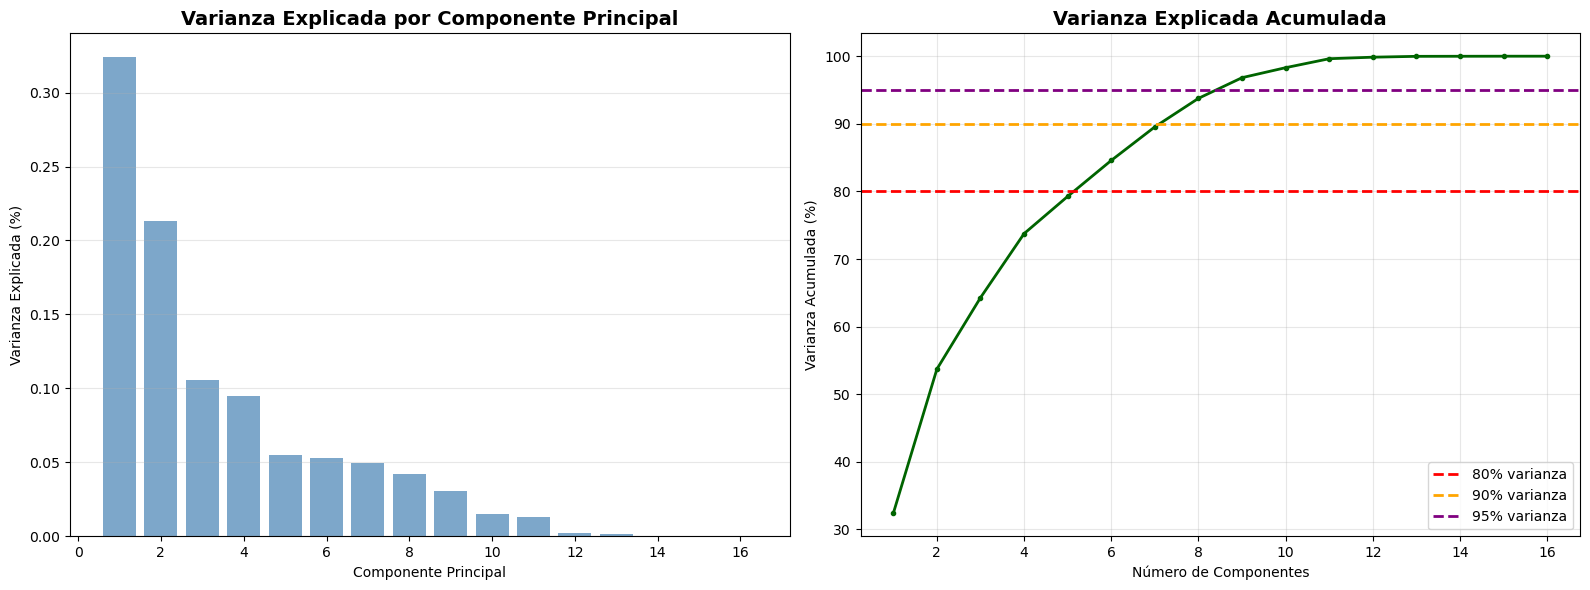

Componentes para 80% de varianza: 6
Componentes para 90% de varianza: 8
Componentes para 95% de varianza: 9


In [ ]:
# Visualizar varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Varianza por componente
n_components_to_plot = min(30, len(explained_variance))
axes[0].bar(range(1, n_components_to_plot+1), explained_variance[:n_components_to_plot], 
            color='steelblue', alpha=0.7)
axes[0].set_title('Varianza Explicada por Componente Principal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Varianza acumulada
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, 
             marker='o', markersize=3, linewidth=2, color='darkgreen')
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% varianza')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% varianza')
axes[1].axhline(y=95, color='purple', linestyle='--', linewidth=2, label='95% varianza')
axes[1].set_title('Varianza Explicada Acumulada', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Encontrar número de componentes para diferentes umbrales
for threshold in [0.80, 0.90, 0.95]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Componentes para {threshold*100:.0f}% de varianza: {n_components}")

### 8.2 Aplicar PCA con Número Óptimo de Componentes

In [ ]:
# Definir número de componentes (90% de varianza como compromiso)
variance_threshold = 0.90
n_components_optimal = np.argmax(cumulative_variance >= variance_threshold) + 1

print(f"Número óptimo de componentes para {variance_threshold*100:.0f}% varianza: {n_components_optimal}")
print(f"Reducción de dimensionalidad: {X_train.shape[1]} -> {n_components_optimal}")
print(f"Porcentaje de reducción: {(1 - n_components_optimal/X_train.shape[1])*100:.1f}%")

Número óptimo de componentes para 90% varianza: 8
Reducción de dimensionalidad: 14 -> 8
Porcentaje de reducción: 42.9%


In [ ]:
# Aplicar PCA con n_components_optimal
pca = PCA(n_components=n_components_optimal, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Convertir a DataFrame
pca_columns = [f'PC{i+1}' for i in range(n_components_optimal)]
X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_columns, index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_columns, index=X_test.index)


print("PCA APLICADO EXITOSAMENTE")

print(f"Shape Train original: {X_train.shape}")
print(f"Shape Train PCA: {X_train_pca_df.shape}")
print(f"\nVarianza total explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

X_train_pca_df.head()

PCA APLICADO EXITOSAMENTE
Shape Train original: (203517, 14)
Shape Train PCA: (203517, 8)

Varianza total explicada: 93.89%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-1.454658,-0.713440,0.404936,0.250529,-0.094892,0.749807,0.842666,0.001217
1,-0.879578,-0.593836,0.430651,0.145175,-0.107269,0.757433,0.841084,0.037347
2,-0.219332,1.727762,0.547472,-1.306703,-0.097447,0.763964,0.838603,0.015266
3,-1.241175,-1.167385,0.415392,0.052351,-0.096748,0.747740,0.842566,-0.002393
4,1.615068,0.525132,0.476186,-0.646060,-0.091280,0.746714,0.835477,0.000001


### 8.3 Análisis de Componentes Principales

In [ ]:
# Contribución de features originales a cada componente principal
components_df = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=X_train.columns
)


print("COMPOSICIÓN DE LOS PRIMEROS 5 COMPONENTES PRINCIPALES")

for i in range(min(5, n_components_optimal)):
    pc_name = f'PC{i+1}'
    print(f"\n{pc_name} (Varianza explicada: {pca.explained_variance_ratio_[i]*100:.2f}%):")
    top_features = components_df[pc_name].abs().sort_values(ascending=False).head(10)
    for feat, weight in top_features.items():
        print(f"  {feat:50s}: {weight:7.4f}")

COMPOSICIÓN DE LOS PRIMEROS 5 COMPONENTES PRINCIPALES

PC1 (Varianza explicada: 32.43%):
  Y Coordinate_standardized                         :  0.7114
  X Coordinate_standardized                         :  0.6812
  Distance Crime To Police Station_standardized     :  0.1706
  Domestic_tag                                      :  0.0264
  Location_Description_freq                         :  0.0051
  Nearest_Police_Station_District_freq              :  0.0043
  Day Time_Early Morning                            :  0.0040
  Day Time_Night                                    :  0.0023
  Day Time_Morning                                  :  0.0017
  Season_Winter                                     :  0.0012

PC2 (Varianza explicada: 21.36%):
  Distance Crime To Police Station_standardized     :  0.9585
  X Coordinate_standardized                         :  0.2821
  Y Coordinate_standardized                         :  0.0404
  Day_sin                                           :  0.0076
  Day Ti

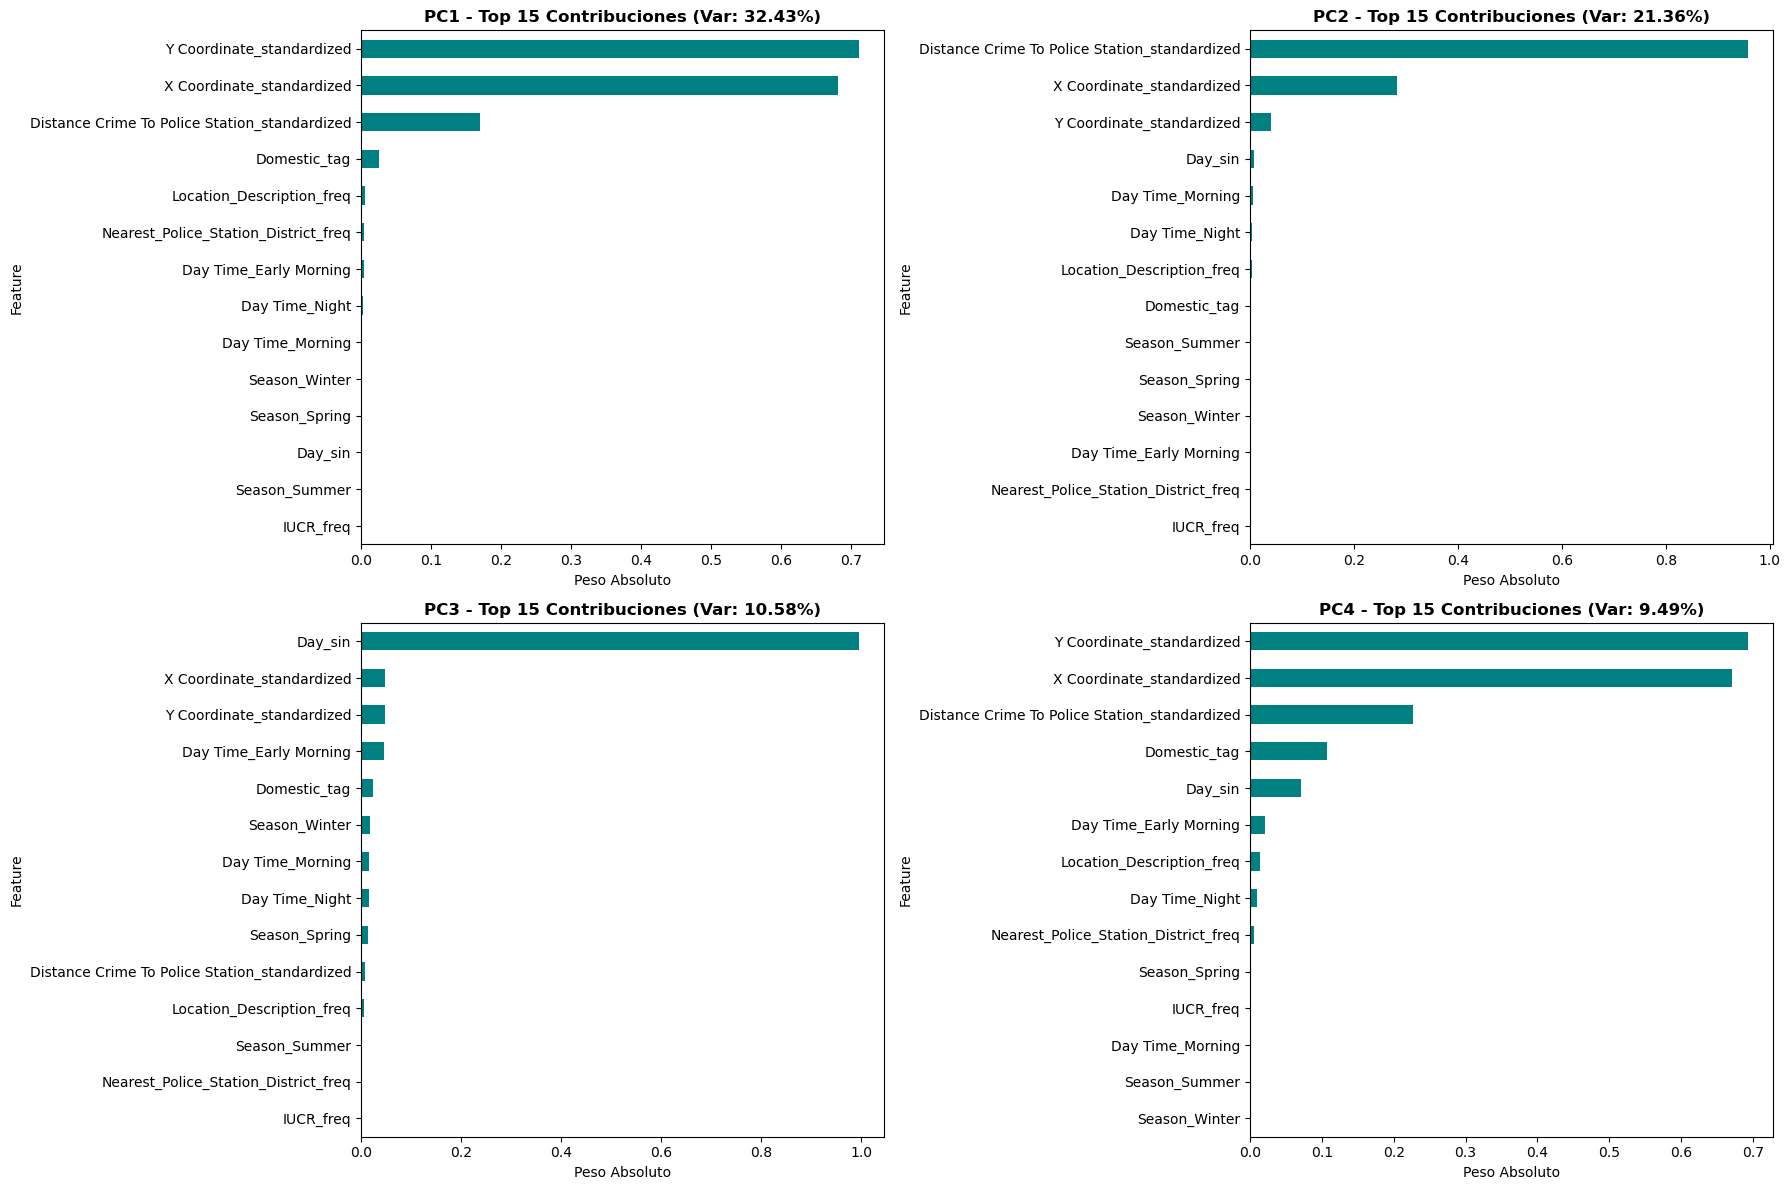

In [ ]:
# Visualizar contribuciones de las primeras PCs
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i in range(min(4, n_components_optimal)):
    pc_name = f'PC{i+1}'
    top_contrib = components_df[pc_name].abs().sort_values(ascending=False).head(15)
    
    top_contrib.plot(kind='barh', ax=axes[i], color='teal')
    axes[i].set_title(f'{pc_name} - Top 15 Contribuciones (Var: {pca.explained_variance_ratio_[i]*100:.2f}%)', 
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Peso Absoluto')
    axes[i].set_ylabel('Feature')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Unir X e y en un solo DataFrame
train_final = X_train_pca_df.copy()
train_final['Arrest_tag'] = y_train.values

test_final = X_test_pca_df.copy()
test_final['Arrest_tag'] = y_test.values

# Guardar datasets finales
train_final.to_csv("../datasets/chicago_crimes_and_stations_2024_final_PCA.csv", index=False)
test_final.to_csv("../datasets/chicago_crimes_and_stations_2024_final_PCA_test.csv", index=False)